<a href="https://colab.research.google.com/github/ShadenAhmed/DataScience-Project/blob/main/DateScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Collecting Data


##1.1 Gold prices

In [429]:
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
!pip install gnews

In [430]:

gold_symbol = "GC=F"
start_date = "2020-01-01"
end_date = "2026-1-31"

gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)

print(gold_raw_data.head()) # first five days of 2020
print(gold_raw_data.tail()) # last days in 2026

gold_raw_data.to_csv("gold_prices_raw.csv")


/tmp/ipykernel_12282/133012054.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.199951  1552.699951  1530.099976  1530.099976    107
2020-01-06  1566.199951  1580.000000  1560.400024  1580.000000    416
2020-01-07  1571.800049  1576.300049  1558.300049  1558.300049     47
2020-01-08  1557.400024  1604.199951  1552.300049  1579.699951    236
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-01-26  5079.700195  5095.600098  5052.200195  5081.500000     180
2026-01-27  5079.899902  5079.899902  5079.899902  5079.899902      34
2026-01-28  5301.600098  5301.600098  5301.600098  5301.600098  112054
2026-01-29  53

## 1.2 Geopolitical News
Collected in phase 1 but the size of data were too small so in phase 2 we decide to collect more data from the same source to improve data quality for conducting analysis

In [475]:

from gnews import GNews
import pandas as pd
import time

google_news = GNews(
    language='en',
    max_results=100,
    start_date=(2020,1,1),
    end_date=(2026,1,1)
)

keywords = [
"geopolitical tensions",
"war",
"geopolitical risk",
"global conflict",
"russia ukraine",
"middle east tensions",
"political instability",
"economic sanctions",
"financial crisis",
"inflation crisis"
]

articles = []

for word in keywords:
    news = google_news.get_news(word)

    for n in news:
        articles.append({
            "title": n["title"],
            "date": n["published date"],
            "url": n["url"],
            "topic": word
        })

    time.sleep(2)

df = pd.DataFrame(articles)

print("Total geopolitical news:", len(df))

df.to_csv("raw_news.csv", index=False)

Total geopolitical news: 1000


## 1.3 Global geopolitical conflict

Our secondary dataset

In [432]:
import pandas as pd

url = "https://raw.githubusercontent.com/ShadenAhmed/DataScience-Project/refs/heads/main/geopolitical_conflict_risk_dataset.csv"
secondary_df = pd.read_csv(url)

columns_needed = [
    "country",
    "month",
    "inflation_rate",
    "gdp_growth_pct",
    "border_disputes_count",
    "sanctions_active",
    "instability_score",
    "conflict_escalation_6m"
]

secondary_df = secondary_df[columns_needed]

secondary_df["month"] = pd.to_datetime(secondary_df["month"], errors="coerce")

secondary_df = secondary_df.dropna(subset=["month"])

secondary_df.head()

,country,month,inflation_rate,gdp_growth_pct,border_disputes_count,sanctions_active,instability_score,conflict_escalation_6m
0,USA,2020-01-01,5.308678,6.737638,3,0,52.436131,0
1,USA,2020-02-01,7.878490,4.467635,1,0,98.474060,1
2,USA,2020-03-01,11.285611,-0.030766,0,0,80.755509,1
3,USA,2020-04-01,5.594405,0.155373,4,0,58.176382,0
4,USA,2020-05-01,10.483152,0.755706,5,0,60.718597,0


Uploaded the secondary dataset and chooses the relevant columns also convert the month column to datetime to ensure its consistent before perform EDA

#2. Data Processing and Cleaning


## 2.1 Geopolitical news data

In [433]:
#imports + read

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("raw_news.csv")

#inspect dataset

df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1000 non-null   object
 1   date    1000 non-null   object
 2   url     1000 non-null   object
 3   topic   1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


,title,date,url,topic
count,1000,1000,1000,1000
unique,980,659,983,10
top,Sen. Rick Scott Issues Weekly Update on Biden’...,"Tue, 17 Jun 2025 07:00:00 GMT",https://news.google.com/rss/articles/CBMilAFBV...,geopolitical tensions
freq,4,9,2,100


**Inspection result:** date is stored as object type and requires conversion to datetime. Duplicate rows were found while no missing values were detected in the dataset.

In [434]:
#cleaning the data

nltk.download('stopwords')
nltk.download('wordnet')

# Date conversion to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True).dt.date


#Remove duplicates by url to be more accurate
df = df.drop_duplicates(subset=["url"])

#Even though no missing titles were found during the previous step,
#we still need to ensure the dataset is clean and reliable before further analysis.
df = df.dropna(subset=["title"])

#cleening the text
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

    # To lowercase
    words = text.lower().split()

    # Lemmatization
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]

    return " ".join(clean_words)

#side by side comparison
df["title_clean"] = df["title"].apply(clean_text)
df[["title", "title_clean"]].head(5)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,title,date,url,topic,title_clean
0,Top Geopolitical Risks of 2025 - S&P Global,2024-05-18,https://news.google.com/rss/articles/CBMihgFBV...,geopolitical tensions,top geopolitical risk 2025 global
1,Geopolitical tensions are laying bare fragilit...,2024-10-16,https://news.google.com/rss/articles/CBMi7AFBV...,geopolitical tensions,geopolitical tension laying bare fragility glo...
2,Defending the North Amid Rising Geopolitical T...,2025-01-14,https://news.google.com/rss/articles/CBMihgFBV...,geopolitical tensions,defending north amid rising geopolitical tensi...
3,The green transition and geopolitical tensions...,2023-11-21,https://news.google.com/rss/articles/CBMifkFVX...,geopolitical tensions,green transition geopolitical tension cepr
4,Top 5 Geopolitical Threats to Businesses in 20...,2025-02-20,https://news.google.com/rss/articles/CBMinAFBV...,geopolitical tensions,top geopolitical threat business 2025 shrm


We will create a binary **event indicator** using specific keywords to identify geopolitical headlines, converting the news text into structured data that can be compared with gold price movements:

In [435]:
#fearure engineering:
#convert unstucutured text to stucutured text by creating an event indicator

keywords = ["war", "conflict", "invasion", "attack",
            "sanction", "military", "tension", "crisis","crises"]

def detect_event(text):
    return 1 if any(word in text for word in keywords) else 0
df["event_indicator"] = df["title_clean"].apply(detect_event)
df["event_indicator"].value_counts()

#a monthgly event count
df["year_month"] = pd.to_datetime(df["date"]).dt.to_period("M")
monthly_events = df.groupby("year_month")["event_indicator"].sum()

monthly_events

,event_indicator
year_month,
2020-01,5
2020-02,1
2020-03,2
2020-04,0
2020-05,2
...,...
2025-09,21
2025-10,16
2025-11,20


News events will be organized by **month** to identify periods of higher geopolitical activity:

In [436]:
#sort by date
df = df.sort_values("date")
df[["date", "title_clean", "event_indicator"]].head()

,date,title_clean,event_indicator
758,2020-01-01,effectiveness economic sanction security tool ...,1
80,2020-01-06,stop escalation urge chief geopolitical tensio...,1
125,2020-01-08,photo essay combat veteran tell need know war ...,1
153,2020-01-09,opinion really must stop starting war publishe...,1
859,2020-01-11,2008 2009 global financial crisis corporate fi...,1


In [437]:
#save clean dataset

clean_news_data = df[[
    "date",
    "title_clean",
    "event_indicator",
    "year_month"
]].copy()

clean_news_data.to_csv("clean_news_data.csv", index=False)

print("Clean dataset saved:", clean_news_data.shape)

Clean dataset saved: (983, 4)


##2.2 Gold prices data


In [438]:
import pandas as pd

df = pd.read_csv("gold_prices_raw.csv")
#Initial Inspection
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 0 to 1531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1532 non-null   object
 1   Close   1531 non-null   object
 2   High    1531 non-null   object
 3   Low     1531 non-null   object
 4   Open    1531 non-null   object
 5   Volume  1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB


,Price,Close,High,Low,Open,Volume
count,1532,1531,1531,1531,1531,1531
unique,1532,1405,1386,1388,1395,883
top,2026-01-30,1815.9000244140625,1813.5,1784.0,1794.300048828125,6
freq,1,4,4,4,4,10


In [439]:
#Renaming Columns
df.rename(columns={'Price': 'Date'}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
3,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
4,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416


In [440]:
#Removing Metadata Rows
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
1,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
2,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
3,2020-01-07,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47
4,2020-01-08,1557.4000244140625,1604.199951171875,1552.300048828125,1579.699951171875,236


In [441]:
df['Date'] = pd.to_datetime(df['Date'])
#Converting Data Types
numeric_cols = ['Close','High','Low','Open','Volume']
df[numeric_cols] = df[numeric_cols].astype(float)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0


In [442]:
#Removing Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [443]:
#Sorting by Date
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [444]:
#Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161


In [445]:
#Compute daily volatility
df['Volatility'] = df['High'] - df['Low']
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902


In [446]:
#Add new variable (Year) from the Date column
df['Year'] = df['Date'].dt.year
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951,2020
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020


In [447]:
#Handling Missing Values
df.isnull().sum()
df.dropna(inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
5,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [448]:
#Outliers analyzing
Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Daily_Return'] < Q1 - 1.5*IQR) |
              (df['Daily_Return'] > Q3 + 1.5*IQR)]
print(outliers.head())

         Date        Close         High          Low         Open  Volume  \
39 2020-02-28  1564.099976  1642.500000  1564.099976  1640.300049   289.0   
41 2020-03-03  1642.099976  1645.300049  1594.000000  1594.500000   610.0   
48 2020-03-12  1589.300049  1647.500000  1566.400024  1637.000000   256.0   
49 2020-03-13  1515.699951  1589.800049  1513.800049  1574.900024    89.0   
51 2020-03-17  1524.900024  1537.699951  1469.300049  1469.300049   122.0   

    Daily_Return  Volatility  Year  
39     -0.046281   78.400024  2020  
41      0.031275   51.300049  2020  
48     -0.031741   81.099976  2020  
49     -0.046310   76.000000  2020  
51      0.026247   68.399902  2020  


Since the outliers is important in analyze the effects of geopolitical events we decide to kept it.

In [449]:
#Saved cleaned and processed dataset
df.to_csv("gold_prices_cleaned.csv", index=False)


#3. Exploratory Data Analysis

## 3.1 EDA for Gold prices primary data

Checking the size of the dataset...
Dataset Size: 1529 rows and 9 columns

What kinds of data are in each column?
float64           7
datetime64[ns]    1
int64             1
Name: count, dtype: int64


/tmp/ipykernel_12282/3871601951.py:23: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(df.dtypes))


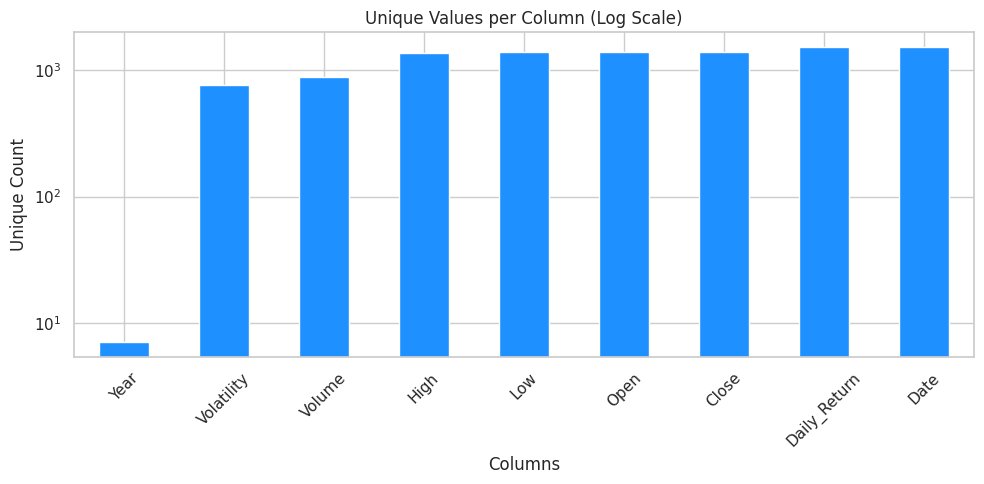


Are there any missing values in our dataset?
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Daily_Return    0
Volatility      0
Year            0
dtype: int64

Summary statistics for our gold price data:
                                Date        Close         High          Low  \
count                           1529  1529.000000  1529.000000  1529.000000   
mean   2023-01-16 00:35:47.285807616  2225.793718  2237.959778  2213.067102   
min              2020-01-03 00:00:00  1477.300049  1484.000000  1452.099976   
25%              2021-07-12 00:00:00  1796.400024  1804.199951  1787.300049   
50%              2023-01-17 00:00:00  1922.099976  1929.400024  1913.699951   
75%              2024-07-25 00:00:00  2415.000000  2429.000000  2395.500000   
max              2026-01-30 00:00:00  5318.399902  5586.200195  5301.600098   
std                              NaN   701.848991   708.633551   695.037235   

              Open    

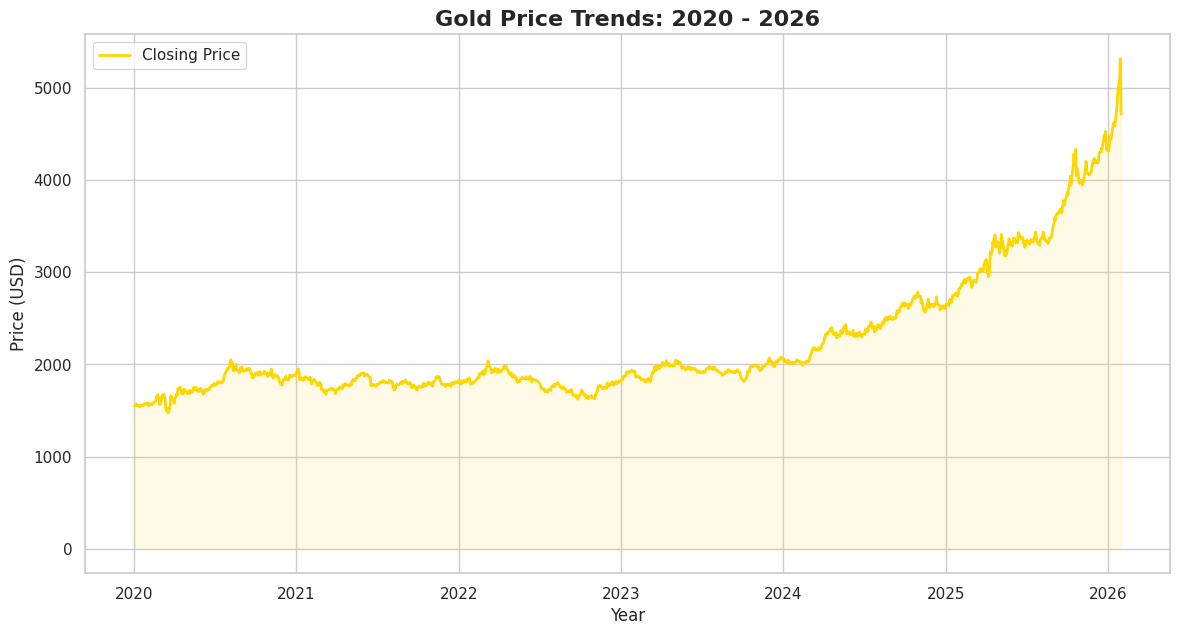

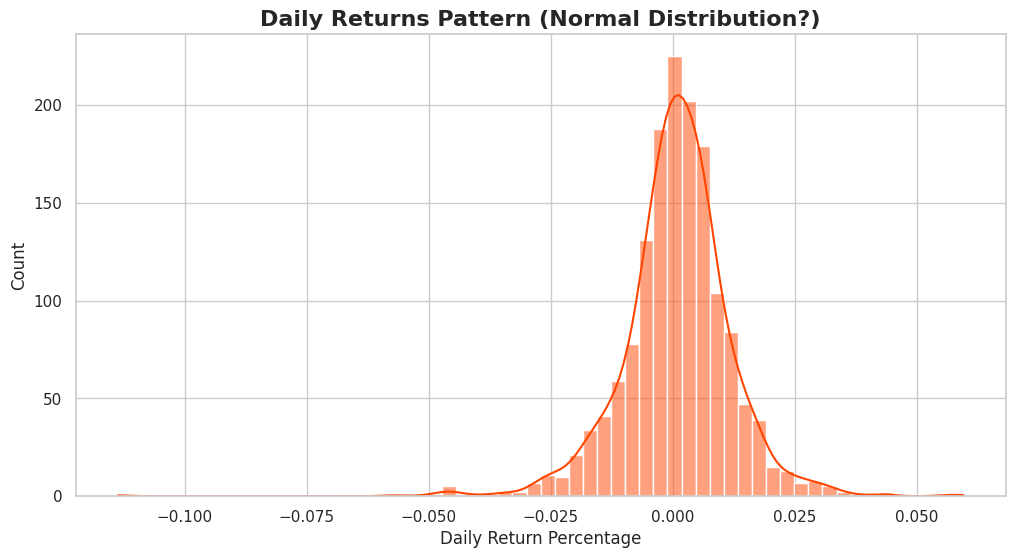

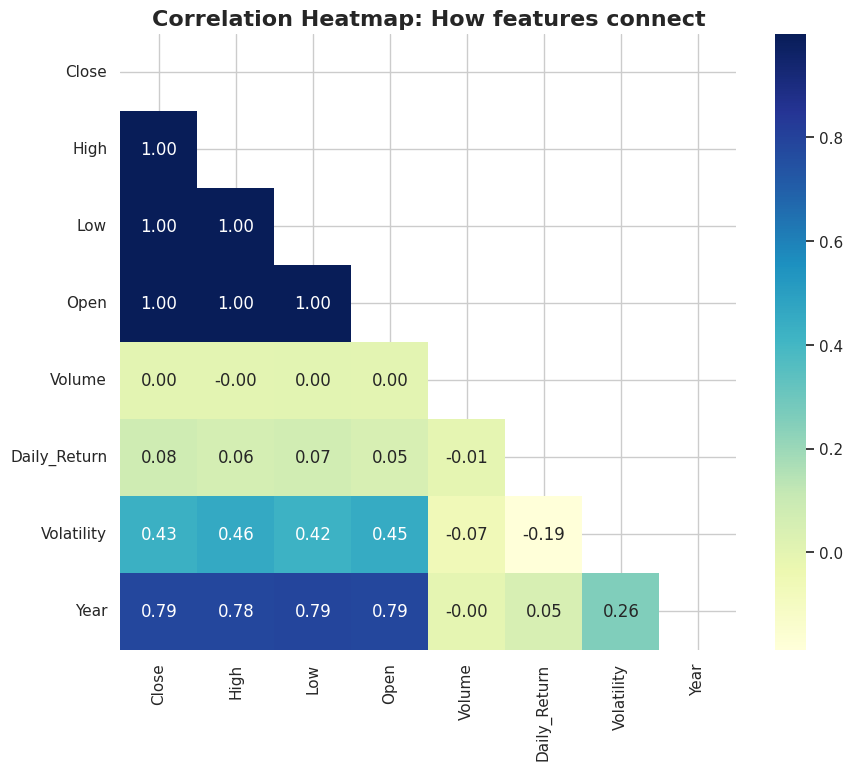

/tmp/ipykernel_12282/3871601951.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Daily_Return', data=df, palette="husl")


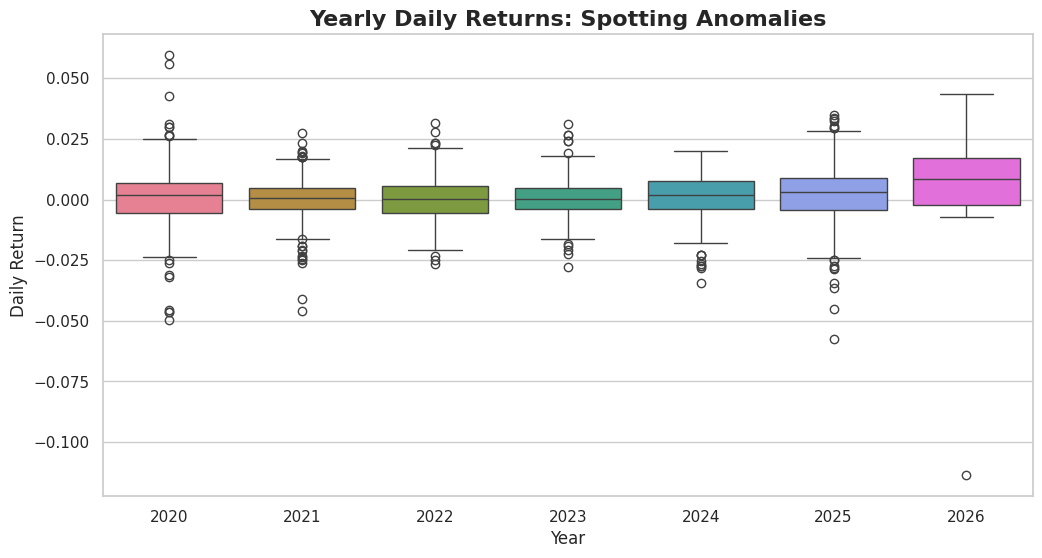

In [450]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Determinig the styles and colors of the graphs
sns.set_theme(style="whitegrid")
vibrant_gold = "#FFD700"
sky_blue = "#1E90FF"
sunset_orange = "#FF4500"

# Loading the gold price data
df = pd.read_csv('gold_prices_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])


#Checking how big our data is and what kind of information we have.
print("Checking the size of the dataset...")
print(f"Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns")

# Looking at the data types (Advanced_eda style)
print("\nWhat kinds of data are in each column?")
print(pd.value_counts(df.dtypes))

# Visualizing how unique the data is
plt.figure(figsize=(10, 5))
unique_counts = df.nunique().sort_values()
unique_counts.plot.bar(color=sky_blue, title="Unique Values per Column (Log Scale)")
plt.yscale('log')
plt.ylabel("Unique Count")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Checking for any missing information or messy data.
print("\nAre there any missing values in our dataset?")
print(df.isnull().sum())


#STATISTICAL SUMMARIES
print("\nSummary statistics for our gold price data:")
print(df.describe())

#TREND ANALYSIS (Visualizing Prices)
#Checking how gold prices changed over time
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], color=vibrant_gold, linewidth=2, label='Closing Price')
plt.fill_between(df['Date'], df['Close'], color=vibrant_gold, alpha=0.1)
plt.title('Gold Price Trends: 2020 - 2026', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.show()

#PATTERN ANALYSIS (Distribution of Returns)
#This helps in determining the most common daily price changes
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'], bins=60, kde=True, color=sunset_orange)
plt.title('Daily Returns Pattern (Normal Distribution?)', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return Percentage')
plt.show()

#CORRELATION ANALYSIS (Feature Relationships)
plt.figure(figsize=(10, 8))
numeric_only = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_only.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='YlGnBu', fmt='.2f', square=True)
plt.title('Correlation Heatmap: How features connect', fontsize=16, fontweight='bold')
plt.show()

#ANOMALY DETECTION
#Spotting price jumps (outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Daily_Return', data=df, palette="husl")
plt.title('Yearly Daily Returns: Spotting Anomalies', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Daily Return')
plt.show()

###Final EDA Summary (Gold Prices Primary Data)

1. Price Trends and Patterns

 Gold prices were steady for a few years, but starting in 2024, they took off, . Looking at the “daily returns” (how much it changes each day), most of the movements are small and centered around 0%, following a standard bell curve. This means the price growth is consistent rather than just random jumps.

2. Anomalies (The “Weird” Days)

By using boxplots for each year, we spotted some clear outliers. 2020 and 2022 had some crashes, where the price dropped much harder than usual. However, 2024 and 2025 looks a lot more stable even though the price is higher. This suggests the current bull market has less extreme panic than we saw a few years ago.

3. Key Relationship (Correlation)
The heatmap showed that while all the price points (Open, Close, High, Low) move perfectly together, Volume actually has almost no relationship with the price.This is an important insight because it tells us that a high number of trades does not necessarily mean the price will move in a certain direction.

At the end commenting on what was mentioned above, the data is high quality and shows a strong, trending market with occasional historical shocks.

## 3.2 EDA for Geopolitical news primary data

In [451]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

df_news = pd.read_csv("clean_news_data.csv")
# Convert date to datetime object
df_news['date'] = pd.to_datetime(df_news['date'])

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
custom_green = '#2F4A2A'

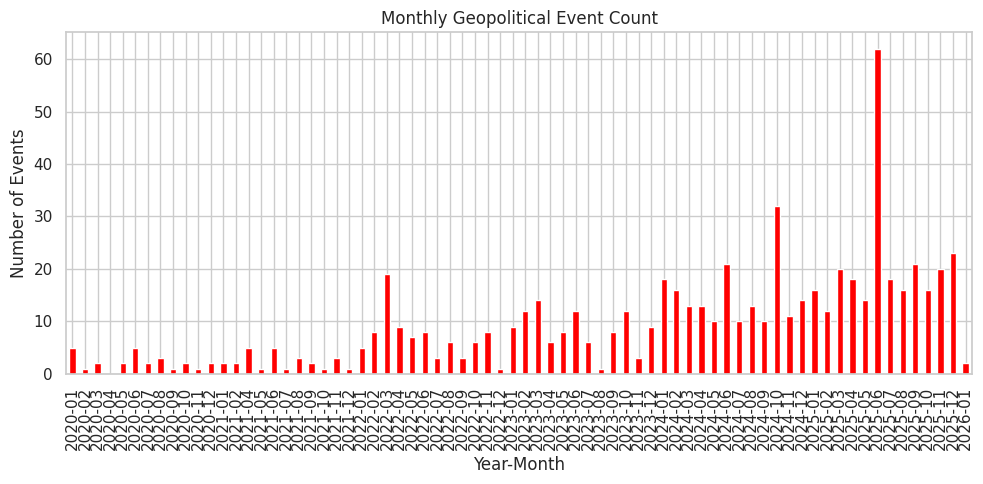

,event_indicator
year_month,
2025-06,62
2024-10,32
2025-12,23
2024-06,21
2025-09,21


In [452]:
#draw barplot of monthly geopolitical event count
monthly_events.plot(kind="bar", figsize=(10,5), color="red")
plt.title("Monthly Geopolitical Event Count")
plt.xlabel("Year-Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#high activity months
monthly_events.sort_values(ascending=False).head(5)

This graph shows the number of geopolitical events reported in the news each month. Based on the results, we observed that some months were more active than others, particularly June 2025, October 2024, and December 2025, indicating that these periods saw a rise in geopolitical tensions or conflicts.


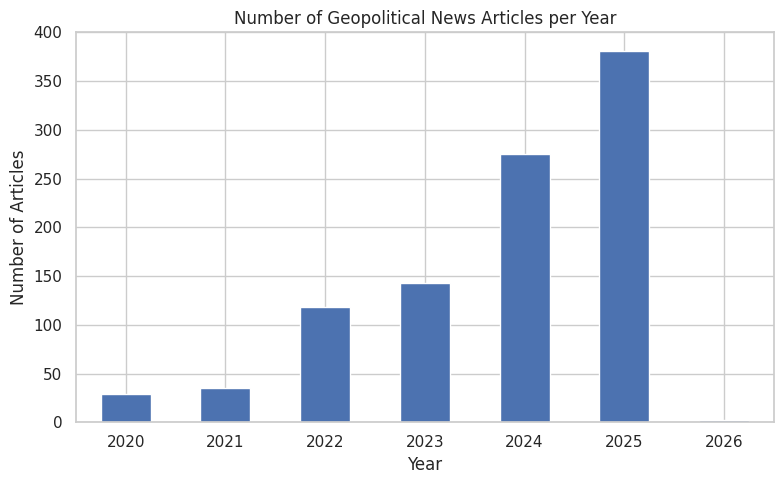

In [453]:
# News distribution per year
plt.figure(figsize=(8,5))

df_news.groupby(df_news.date.dt.year).size().plot(kind='bar')

plt.title("Number of Geopolitical News Articles per Year")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

This bar chart shows the number of geopolitical news articles published each year between 2020 and 2026. We noticed that some years contain more news articles than others, especially the later years, and this shows that they contain more geopolitical events or conflicts.


/tmp/ipykernel_12282/2442848665.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=trend_df, palette='summer')


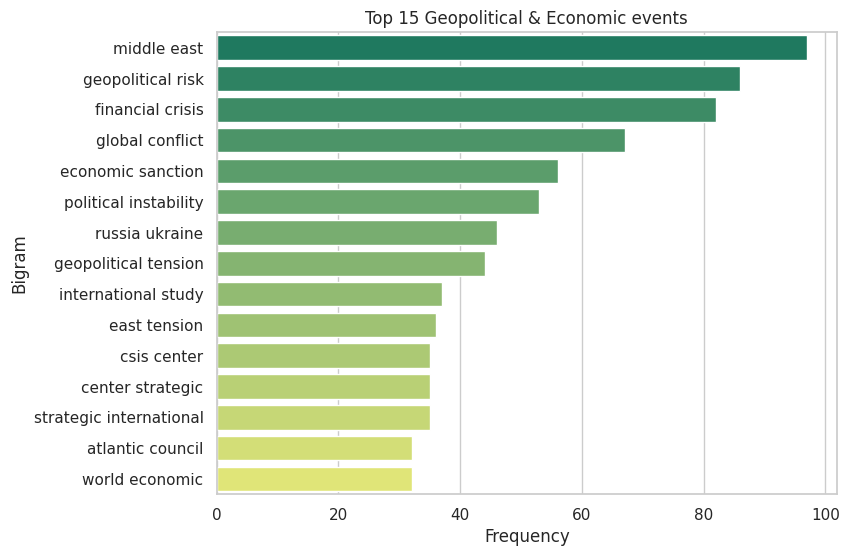

In [454]:
 #Top Bigrams
from sklearn.feature_extraction.text import CountVectorizer

def plot_trends(corpus, n=15):
    vectorizer = CountVectorizer(ngram_range=(2,2))
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    trend_df = pd.DataFrame(words_freq[:n], columns=['Bigram','Frequency'])

    plt.figure(figsize=(8,6))
    sns.barplot(x='Frequency', y='Bigram', data=trend_df, palette='summer')

    plt.title(f'Top {n} Geopolitical & Economic events')
    plt.show()

plot_trends(df_news['title_clean'])

This chart shows the main geopolitical and economic topics that have been commonly covered in the news, such as (the Middle East, financial crises, geopolitical risk, and global conflicts).


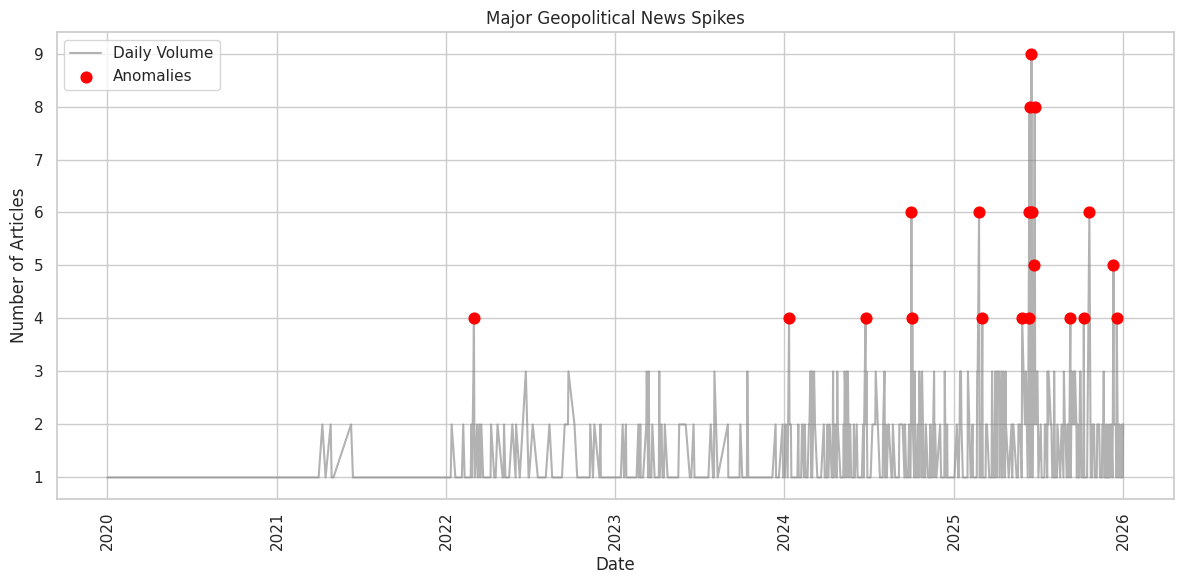

In [455]:
# Anomaly detection
# Daily news volume
daily_news = df_news.groupby('date').size()

# Statistical
mean_vol = daily_news.mean()
std_vol = daily_news.std()

# Detect anomalies
anomalies = daily_news[daily_news > (mean_vol + 2 * std_vol)]

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_news.index, daily_news.values, label='Daily Volume', color='gray', alpha=0.6)

plt.scatter(anomalies.index, anomalies.values,
            color='red', s=60,
            label='Anomalies',
            zorder=5)

plt.title('Major Geopolitical News Spikes')
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.xticks(rotation=90)

plt.legend()
plt.tight_layout()
plt.show()

This graph shows the number of daily geopolitical news articles over time. The gray line represents the typical daily news volume and the red dots represent unusual spikes in news activity and these spikes occur when the number of articles is higher than the average and that indicates significant geopolitical events or crises that have received extensive media coverage

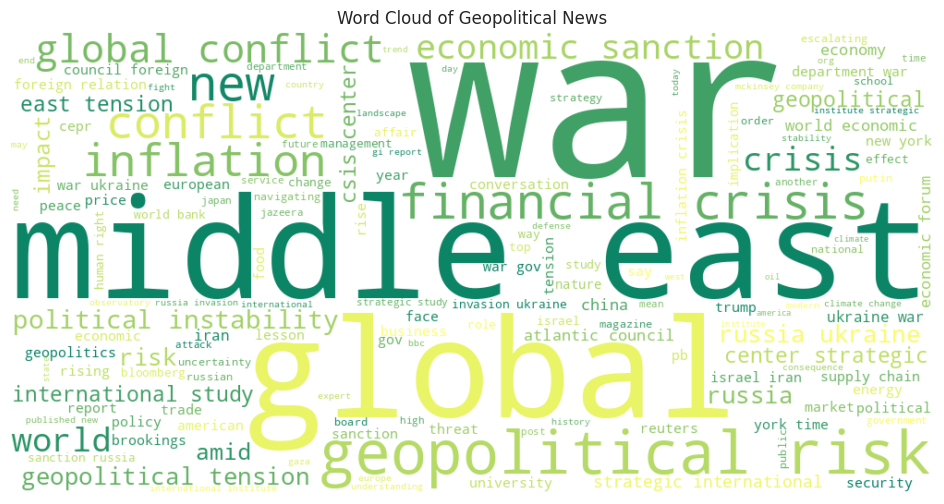

In [456]:
#word cloud
from wordcloud import WordCloud

# Combine all headlines
all_text = " ".join(df_news['title_clean'])

WordCloud = WordCloud(width=1000,
               height=500,
               background_color='white',
               colormap='summer',
               max_words=150).generate(all_text)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(WordCloud, interpolation='bilinear')
plt.axis('off')

plt.title('Word Cloud of Geopolitical News')
plt.show()

This chart provides a visual summary of the most frequently words in news headlines. Larger words indicate words that appear most often, reflecting their importance in the geopolitical topics covered by the news articles. These words include (war, Middle East, and global conflicts)

## 3.3 EDA of merged data (gold prices + Geopolitical news)

In [457]:
df_daily_news = df_news.groupby('date').size().reset_index(name='news_volume')
df_combined = pd.merge(df, df_daily_news, left_on='Date', right_on='date', how='inner')
df_combined.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year,date,news_volume
0,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020,2020-01-06,1
1,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020,2020-01-08,1
2,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020,2020-01-09,1
3,2020-02-05,1557.800049,1560.699951,1547.699951,1553.199951,1305.0,0.004773,13.000000,2020,2020-02-05,1
4,2020-03-23,1567.000000,1567.000000,1490.199951,1505.300049,51.0,0.055930,76.800049,2020,2020-03-23,1


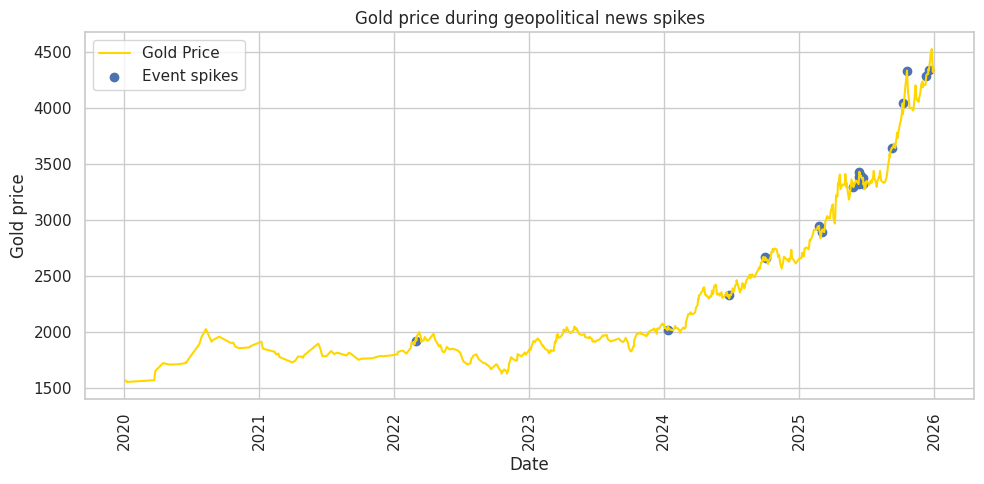

In [458]:
# detect spikes
# Use 'news_volume' from df_combined as the event count for daily analysis
mean_events = df_combined["news_volume"].mean()
std_events = df_combined["news_volume"].std()

spikes = df_combined[df_combined["news_volume"] > mean_events + 2*std_events]

# plot
plt.figure(figsize=(10,5))

# Plot daily Close price for gold
plt.plot(df_combined['date'], df_combined["Close"], label="Gold Price" , color='gold')

plt.scatter(spikes['date'],
            spikes["Close"],
            label="Event spikes")

plt.xticks(rotation=90)
plt.title("Gold price during geopolitical news spikes")
plt.xlabel("Date")
plt.ylabel("Gold price")
plt.legend()

plt.tight_layout()
plt.show()

This visualization shows the daily gold price with markers indicating dates when the geopolitical news volume significantly spiked. This allows us to observe how gold prices behave during periods of high geopolitical activity.

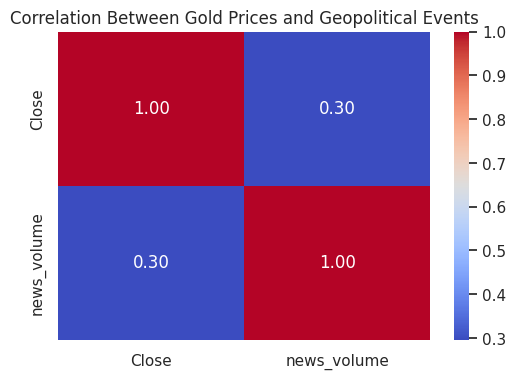

In [459]:
# correlation matrix
# Select only numeric columns relevant for correlation
numeric_cols = ['Close', 'news_volume']
corr_matrix = df_combined[numeric_cols].corr()

# heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Between Gold Prices and Geopolitical Events")
plt.show()

The correlation analysis between gold prices and news volume showed a weak relationship indicating that news volume alone does not definitively explain price movements. However, one possible explanation is that financial markets may react to major events with a delay, meaning that the impact of geopolitical news on gold prices may appear a few days later rather than on the same day.

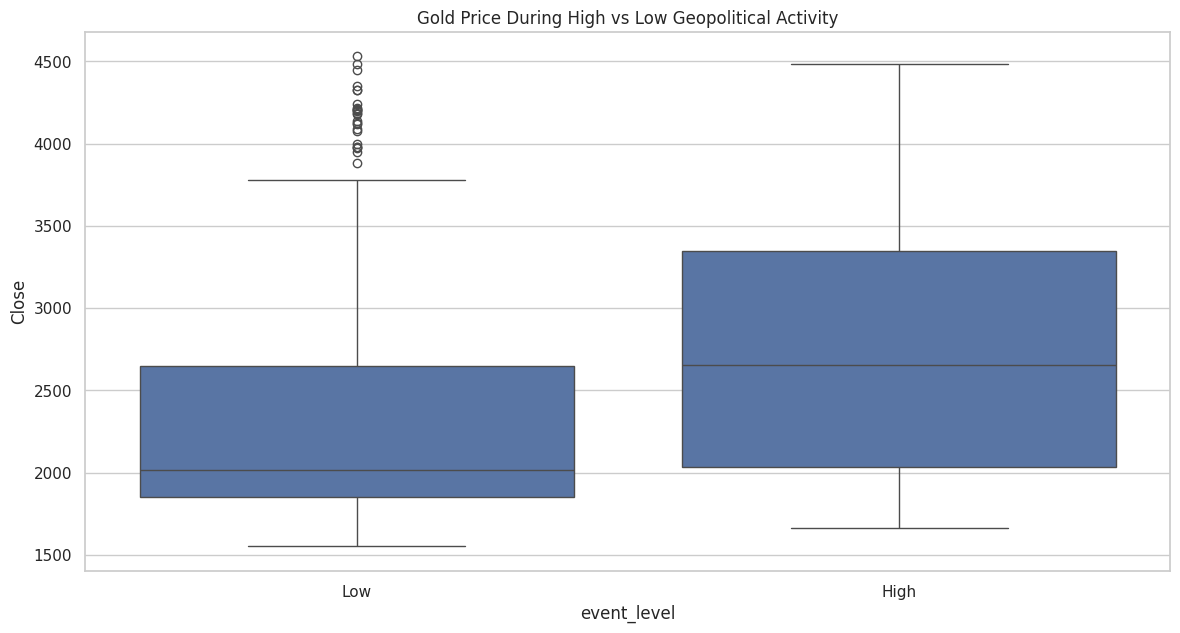

In [460]:
df_combined['event_level'] = df_combined['news_volume'].apply(lambda x: "High" if x > df_combined['news_volume'].mean() else "Low")

sns.boxplot(x='event_level', y='Close', data=df_combined)

plt.title("Gold Price During High vs Low Geopolitical Activity")
plt.show()

This boxplot compares gold prices during months with high and low geopolitical activity. If the median price during high activity is higher it may indicate that gold prices tend to increase during periods of geopolitical tension. In this boxplot we observe that in month of high geopolitical activity gold prices increases

## 3.4 EDA for secondary data

In [461]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [462]:
## secondary_df = pd.read_csv('geopolitical_conflict_risk_dataset.csv')

In [463]:
display(secondary_df.head())
secondary_df.info()

,country,month,inflation_rate,gdp_growth_pct,border_disputes_count,sanctions_active,instability_score,conflict_escalation_6m
0,USA,2020-01-01,5.308678,6.737638,3,0,52.436131,0
1,USA,2020-02-01,7.878490,4.467635,1,0,98.474060,1
2,USA,2020-03-01,11.285611,-0.030766,0,0,80.755509,1
3,USA,2020-04-01,5.594405,0.155373,4,0,58.176382,0
4,USA,2020-05-01,10.483152,0.755706,5,0,60.718597,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   country                 1320 non-null   object        
 1   month                   1320 non-null   datetime64[ns]
 2   inflation_rate          1320 non-null   float64       
 3   gdp_growth_pct          1320 non-null   float64       
 4   border_disputes_count   1320 non-null   int64         
 5   sanctions_active        1320 non-null   int64         
 6   instability_score       1320 non-null   float64       
 7   conflict_escalation_6m  1320 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 82.6+ KB


In [464]:
display(secondary_df.describe())

,month,inflation_rate,gdp_growth_pct,border_disputes_count,sanctions_active,instability_score,conflict_escalation_6m
count,1320,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,2022-09-15 22:54:32.727272704,6.411540,1.941791,2.465152,0.095455,66.971506,0.314394
min,2020-01-01 00:00:00,0.017210,-9.509967,0.000000,0.000000,4.014365,0.000000
25%,2021-05-01 00:00:00,3.069854,-0.172605,1.000000,0.000000,48.202017,0.000000
50%,2022-09-16 00:00:00,5.979951,1.930365,2.000000,0.000000,66.117718,0.000000
75%,2024-02-01 00:00:00,9.116799,3.954005,4.000000,0.000000,84.578126,1.000000
max,2025-06-01 00:00:00,23.144552,14.443685,5.000000,1.000000,149.696509,1.000000
std,NaN,4.120199,3.037963,1.690269,0.293953,26.339773,0.464450


We used the describe() function to extract statistical values, such as the mean, standard deviation, and maximum and minimum values. The goal was to determine the normal value of the instability score. We found that the mean was approximately 66, which suggests a normal value for us. We also observed an anomaly with the maximum value reaching 149.69. This significant difference indicates that geopolitical events have occurred that have impacted instability

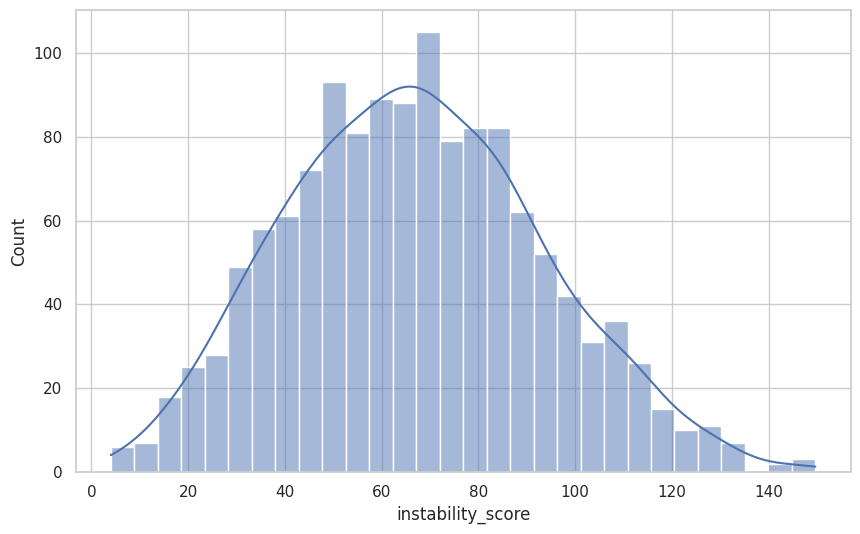

In [465]:
plt.figure(figsize=(10, 6))
sns.histplot(data=secondary_df, x='instability_score', bins=30, kde=True)
plt.show()

We used a histogram to understand how the values ​​are distributed. The goal is to see where most of the data cluster (between 60 and 80) and to confirm that there is a rightward slope that statistically proves the presence of rare anomalies exceeding 140, which we identified in the statistical summary.

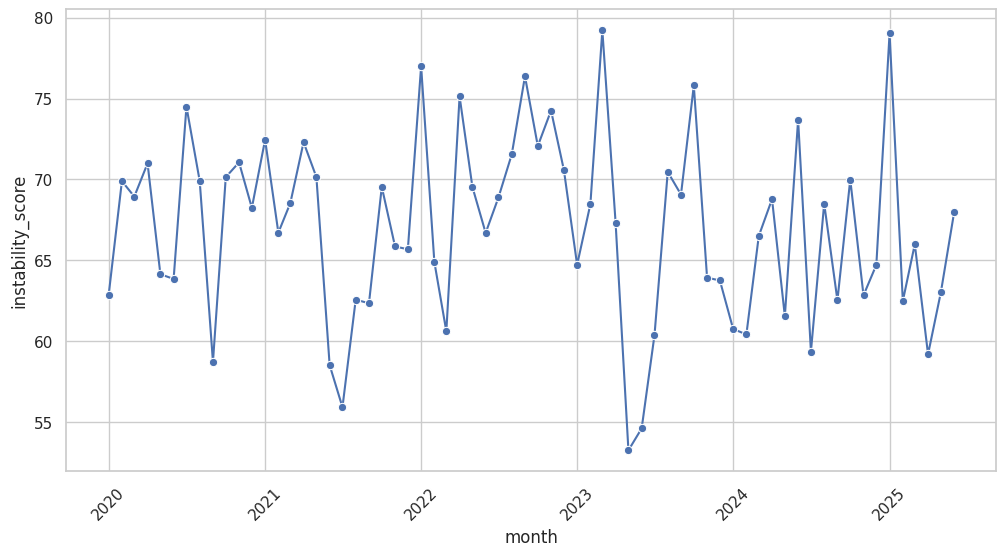

In [466]:
secondary_df['month'] = pd.to_datetime(secondary_df['month'])
global_trend = secondary_df.groupby('month')['instability_score'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=global_trend, x='month', y='instability_score', marker='o')
plt.xticks(rotation=45)
plt.show()

We used a line chart to visualize the evolution of the instability score from 2020 to 2025. The goal of graph is to track data over time and identify specific periods where there were spikes in geopolitical risks such as late 2023.

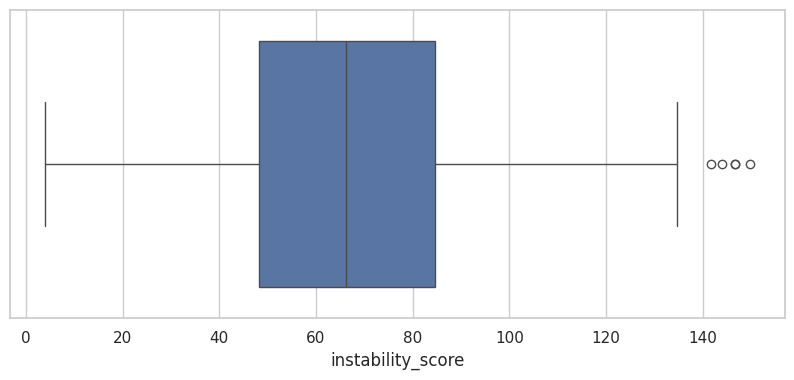

In [467]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=secondary_df, x='instability_score')
plt.show()

We used a boxplot to visualize the spread of data around the median and to accurately identify outliers. This helps us see values ​​that exceed the normal range of the instability index, confirming the unusual spikes (such as the value of 149.69) we observed in the statistical summary.

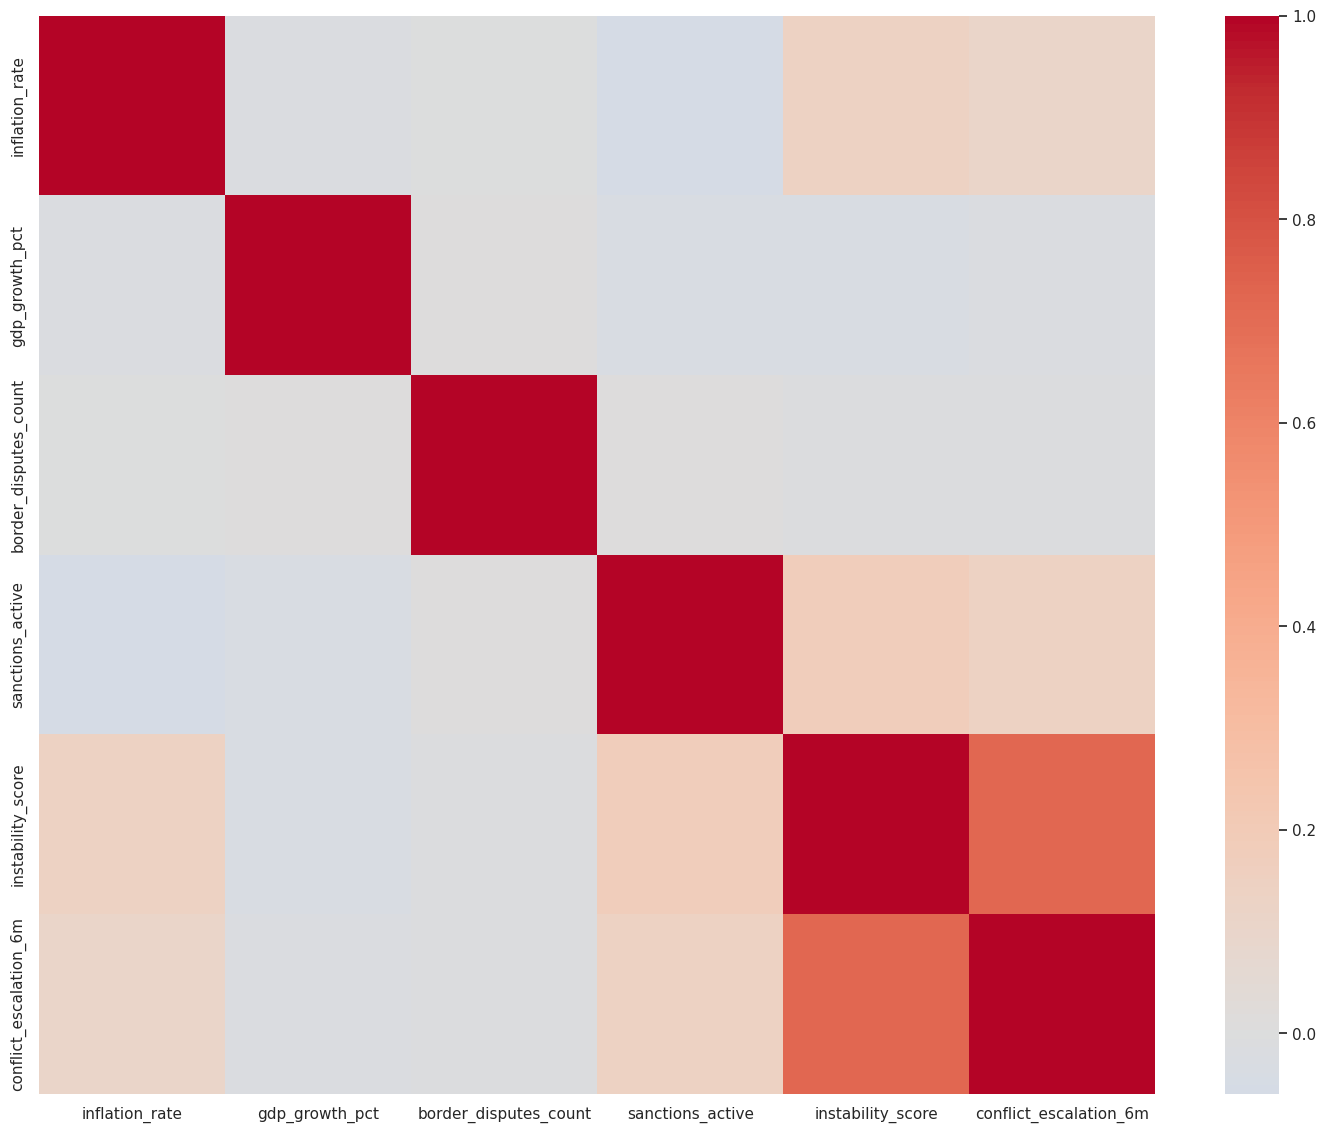

In [468]:
corr_matrix = secondary_df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix , cmap='coolwarm', center=0)
plt.show()

We used a heatmap to measure the strength of the relationship between the instability score and other measures. Our goal is to confirm that increased protests and conflicts raise this score, while decreased political stability leads to increased instability. This analysis helps us understand why the data spikes and changes at some periods.

# Modeling

## 4.1 The Baseline Model

In [469]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

#preparing df_combined:

#Dropping redundancy
df_combined = df_combined.drop(columns=['date', 'event_level', 'Year'])

print("Columns:", df_combined.columns.tolist())
print("Shape:", df_combined.shape)


Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Volatility', 'news_volume']
Shape: (570, 9)



Class Distribution:
Target
STABLE    260
UP        181
DOWN      129
Name: count, dtype: int64
Target
STABLE    0.46
UP        0.32
DOWN      0.23
Name: proportion, dtype: float64


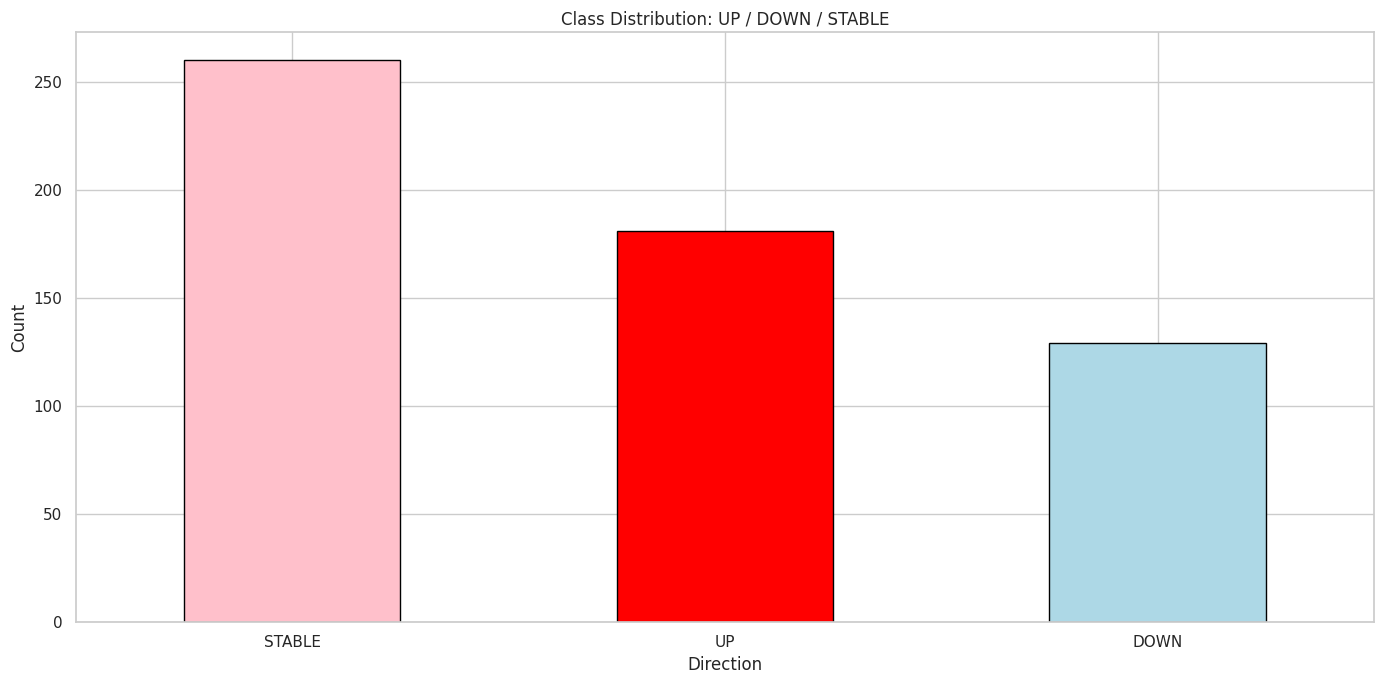

In [470]:
## Creating the target variable

def label_direction(ret):
    if ret > 0.005:       # price went up more than +0.5%
        return 'UP'
    elif ret < -0.005:    # price went down more than -0.5%
        return 'DOWN'
    else:
        return 'STABLE'   # price barely moved

df_combined['Target'] = df_combined['Daily_Return'].apply(label_direction)

# ✅ CHECK: make sure all 3 classes exist and none dominates too heavily
# if one class is 90%+ of the data, the threshold (0.005) needs adjusting
print("\nClass Distribution:")
print(df_combined['Target'].value_counts())
print(df_combined['Target'].value_counts(normalize=True).round(2))  # this is to show percentages

df_combined['Target'].value_counts().plot(
    kind='bar',
    color=['pink', 'red', 'lightblue'],
    edgecolor='black'
)
plt.title('Class Distribution: UP / DOWN / STABLE')
plt.xlabel('Direction')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The class distribution shows that STABLE (45%) is the most frequent class.
This means the baseline model should
predict STABLE for every single day and achieve an accuracy of ~45%.


In [471]:
## check missing values

before = len(df_combined)
df_combined = df_combined.dropna(subset=['Daily_Return', 'news_volume', 'Volatility'])
after = len(df_combined)
print(f"\nRows before dropna: {before}")
print(f"Rows after dropna : {after}")
print(f"Rows dropped      : {before - after}")

if before == after:
    print("No missing values found")
else:
    print(f"Warning: {before - after} rows were dropped")



Rows before dropna: 570
Rows after dropna : 570
Rows dropped      : 0
No missing values found


In [472]:
## Define features (X) and target (y)
features = ['Volume', 'Volatility', 'news_volume']
X = df_combined[features]
y = df_combined['Target']

print("Features:", features)
print("Target classes:", y.unique())

Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'Volatility', 'news_volume']
Target classes: ['UP' 'DOWN' 'STABLE']


We will now proceed to split the data into training and test sets:

In [473]:

# note: shuffle=False keeps the time order intact, important for time series.

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test samples    : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training samples: 456 (80.0%)
Test samples    : 114 (20.0%)


In [474]:
## The baselline model:

dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train_scaled, y_train)
y_pred_strat = dummy_strat.predict(X_test_scaled)

print("\n================ BASELINE MODEL ======================")
print(f"Accuracy: {accuracy_score(y_test, y_pred_strat):.4f}")
print(classification_report(y_test, y_pred_strat, zero_division=0))


================ BASELINE MODEL ======================
Accuracy: 0.3684
              precision    recall  f1-score   support

        DOWN       0.24      0.30      0.27        23
      STABLE       0.41      0.53      0.47        45
          UP       0.41      0.24      0.30        46

    accuracy                           0.37       114
   macro avg       0.35      0.36      0.35       114
weighted avg       0.38      0.37      0.36       114



With an overall accuracy of 35% , our baseline model should represent the minimum threshold that any real model must surpass
to be considered effective.

In [476]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# build model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# model training
rf_model.fit(X_train_scaled, y_train)

# prediction
y_pred_rf = rf_model.predict(X_test_scaled)

# results
print("\n================ RANDOM FOREST MODEL ======================")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, zero_division=0))


================ RANDOM FOREST MODEL ======================
Accuracy: 0.4825
              precision    recall  f1-score   support

        DOWN       0.24      0.30      0.27        23
      STABLE       0.69      0.44      0.54        45
          UP       0.50      0.61      0.55        46

    accuracy                           0.48       114
   macro avg       0.48      0.45      0.45       114
weighted avg       0.52      0.48      0.49       114



The random forest model achieved an accuracy of approximately 48% which is slightly better than the base model. This indicates a small improvement.

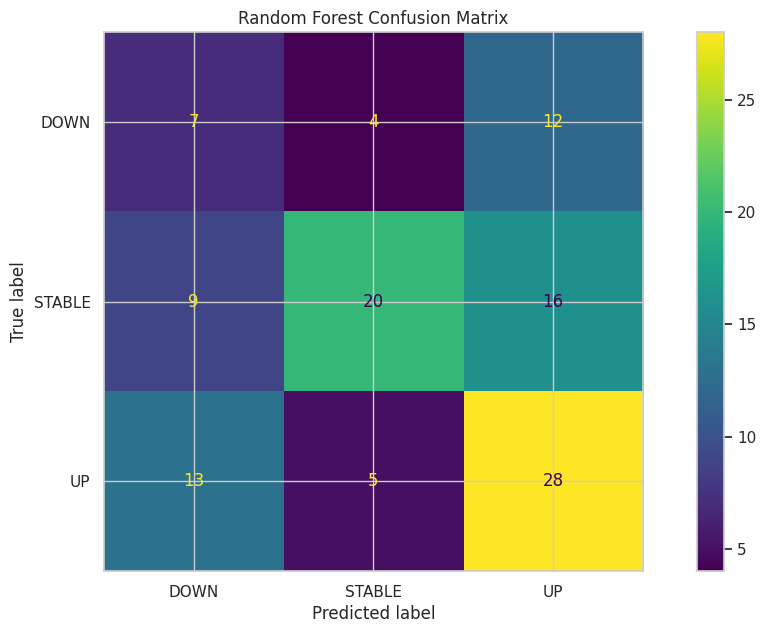

In [477]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

The model predicts the UP category better than the others, but it makes many mistakes between categories. For example it sometimes predicts UP as DOWN and sometimes STABLE as UP. Overall, the performance is average, and there is a clear mix-up between categories.